In [ ]:
# !pip install noisereduce

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from scipy.signal import windows
import noisereduce as nr
import requests
import io

In [2]:
# Load Audio
url = "https://github.com/KevinAndT25/2311532005_KevinAndhika_SpeechProcessing/raw/refs/heads/main/2311532005-kevinandhika-audio.wav"
response = requests.get(url)
audio_data, sr = librosa.load(io.BytesIO(response.content), sr=None)

print(f"Sampling rate: {sr} Hz")
print(f"Durasi: {len(audio_data)/sr:.2f} detik")

Sampling rate: 48000 Hz
Durasi: 124.99 detik


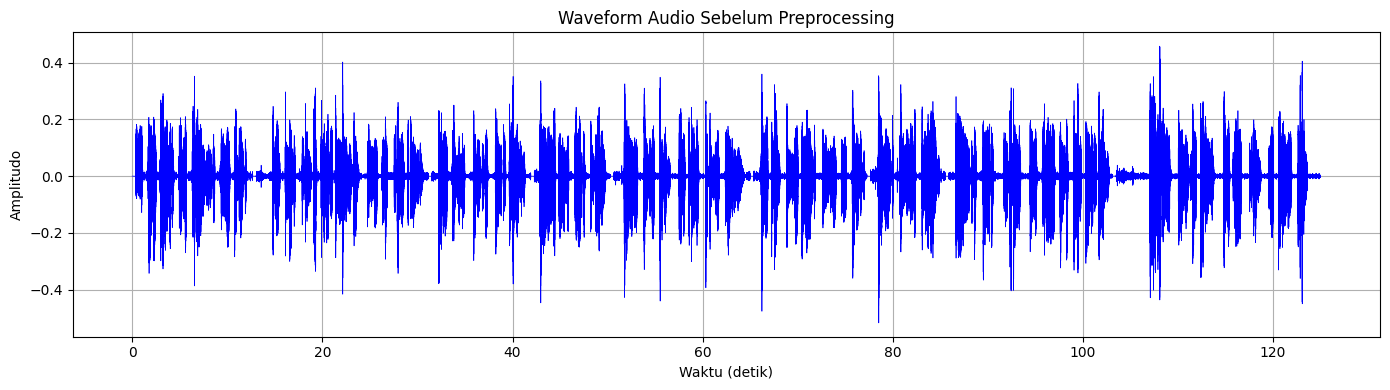

In [3]:
# Visualisasi Waveform
plt.figure(figsize=(14, 4))
time = np.linspace(0, len(audio_data)/sr, len(audio_data))
plt.plot(time, audio_data, color='blue', linewidth=0.5)
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.title('Waveform Audio Sebelum Preprocessing')
plt.grid(True)
plt.tight_layout()
plt.show()

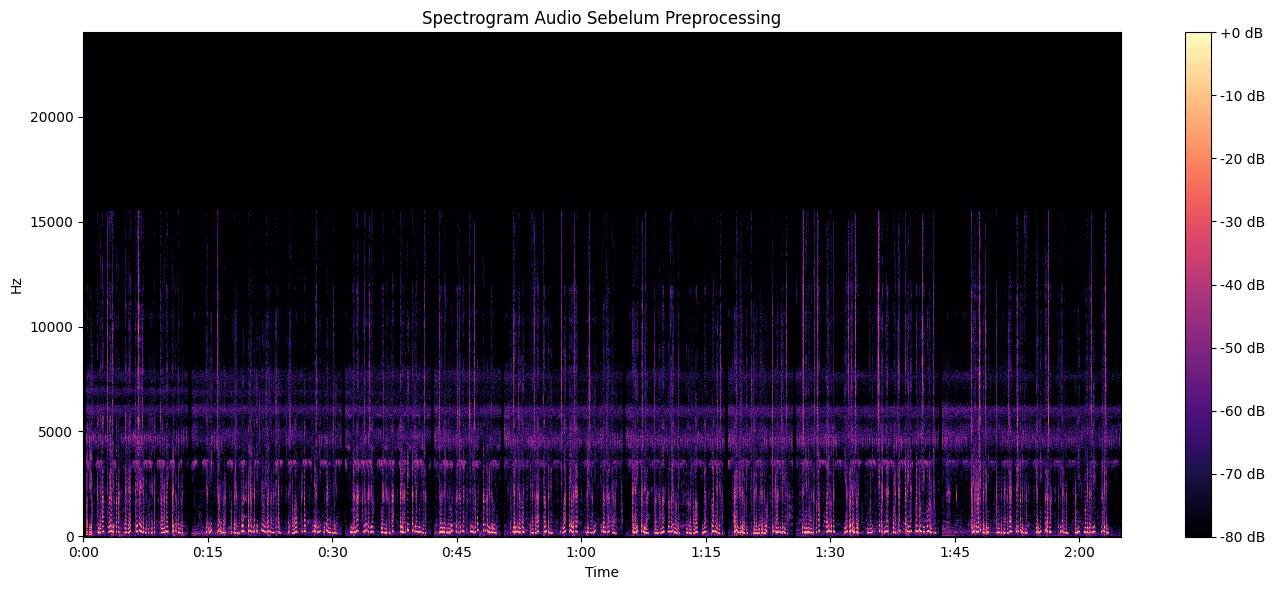

In [4]:
# Representasi Spectogram
plt.figure(figsize=(14, 6))
D = librosa.amplitude_to_db(np.abs(librosa.stft(audio_data)), ref=np.max)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram Audio Sebelum Preprocessing')
plt.tight_layout()
plt.show()

In [5]:
# Preprocessing
audio_processed = audio_data.copy()

audio_processed = audio_processed / np.max(np.abs(audio_processed))

def remove_silence(audio, sr, threshold_db=-40, frame_length=2048, hop_length=512):
    energy = librosa.feature.rms(y=audio, frame_length=frame_length, hop_length=hop_length)[0]
    energy_db = librosa.amplitude_to_db(energy, ref=np.max)
    non_silence_indices = energy_db > threshold_db
    frames = librosa.util.frame(audio, frame_length=frame_length, hop_length=hop_length).T
    min_len = min(len(frames), len(non_silence_indices))
    frames = frames[:min_len]
    non_silence_indices = non_silence_indices[:min_len]
    non_silence_frames = frames[non_silence_indices]
    if len(non_silence_frames) > 0:
        audio_clean = non_silence_frames.flatten()
        return audio_clean
    return audio
audio_processed = remove_silence(audio_processed, sr)

audio_processed = nr.reduce_noise(y=audio_processed, sr=sr, stationary=True)

# Simpan hasil preprocessing
sf.write('2311532005-kevinandhika-preprocessing.wav', audio_processed, sr)

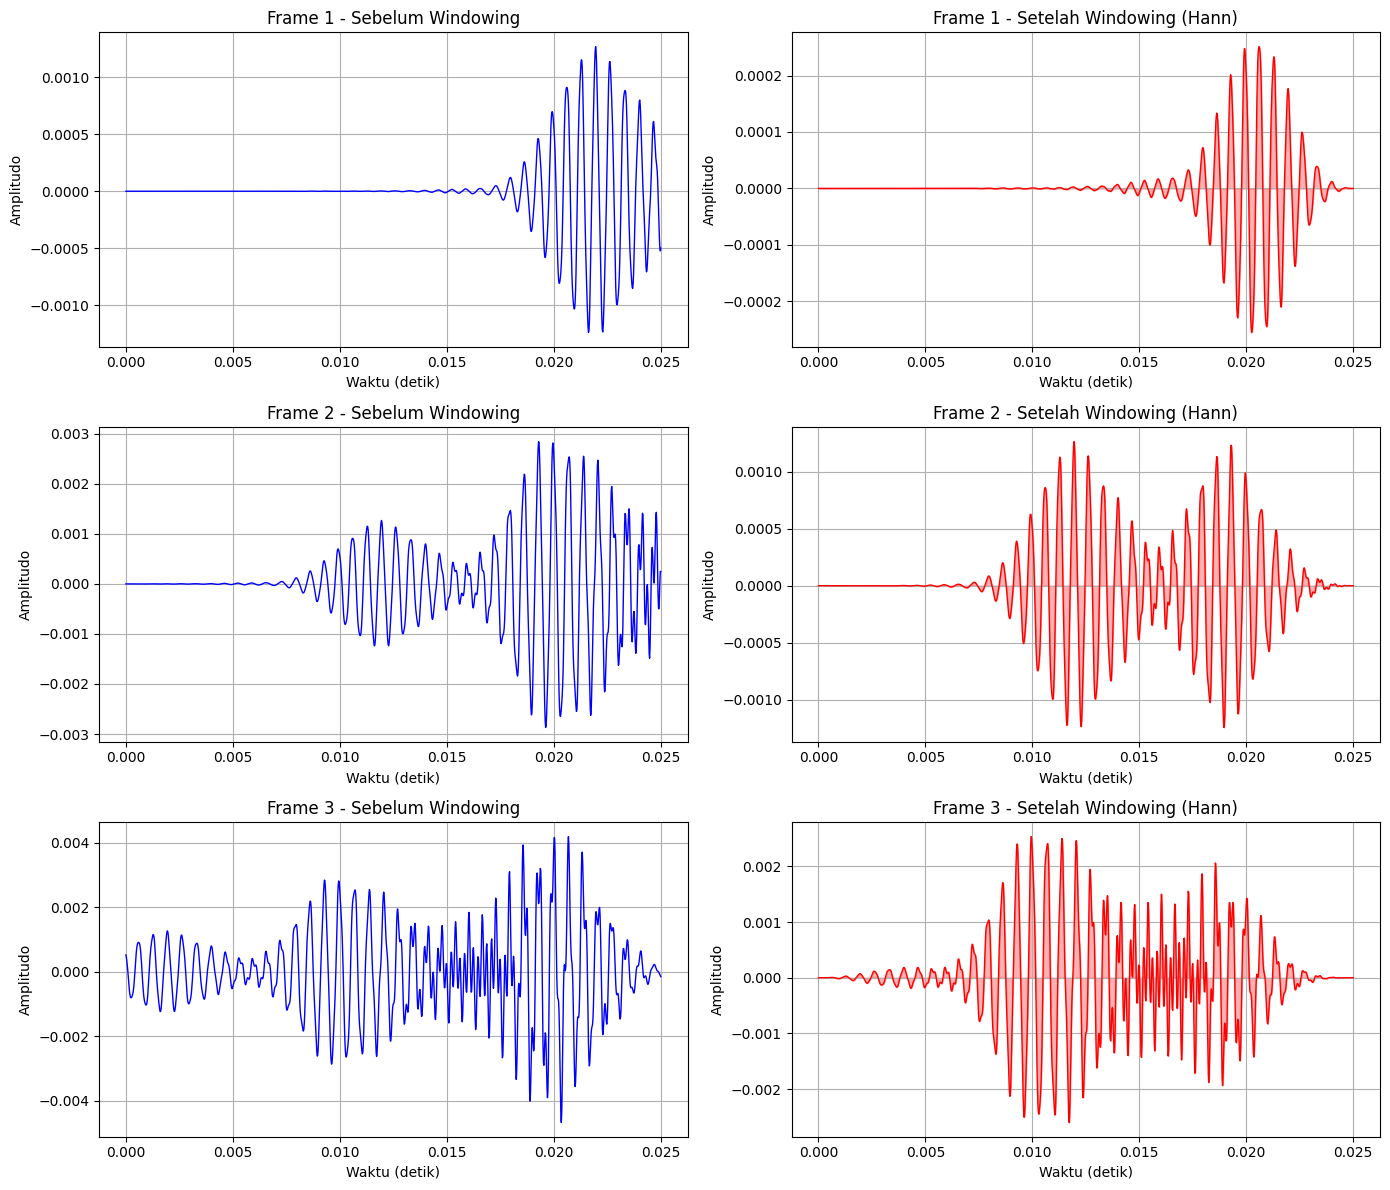

In [7]:
frame_size = int(0.025 * sr)  # 25 ms
hop_length = int(0.010 * sr)   # 10 ms

frames = librosa.util.frame(audio_processed, frame_length=frame_size, hop_length=hop_length).T

# Simpan dan visualisasikan 3 frame pertama dengan windowing
n_frames_to_show = min(3, len(frames))
fig, axes = plt.subplots(n_frames_to_show, 2, figsize=(14, 4 * n_frames_to_show))
if n_frames_to_show == 1:
    axes = axes.reshape(1, -1)

for i in range(n_frames_to_show):
    frame = frames[i]
    window = windows.hann(len(frame))
    windowed_frame = frame * window

    # Simpan file WAV
    sf.write(f'2311532005-kevinandhika-windowing-{i+1}.wav', windowed_frame, sr)

    # Visualisasi frame asli (sebelum windowing)
    time_frame = np.linspace(0, len(frame)/sr, len(frame))
    axes[i, 0].plot(time_frame, frame, color='blue', linewidth=1)
    axes[i, 0].set_title(f'Frame {i+1} - Sebelum Windowing')
    axes[i, 0].set_xlabel('Waktu (detik)')
    axes[i, 0].set_ylabel('Amplitudo')
    axes[i, 0].grid(True)

    # Visualisasi frame setelah windowing
    axes[i, 1].plot(time_frame, windowed_frame, color='red', linewidth=1)
    axes[i, 1].fill_between(time_frame, windowed_frame, alpha=0.3, color='red')
    axes[i, 1].set_title(f'Frame {i+1} - Setelah Windowing (Hann)')
    axes[i, 1].set_xlabel('Waktu (detik)')
    axes[i, 1].set_ylabel('Amplitudo')
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()

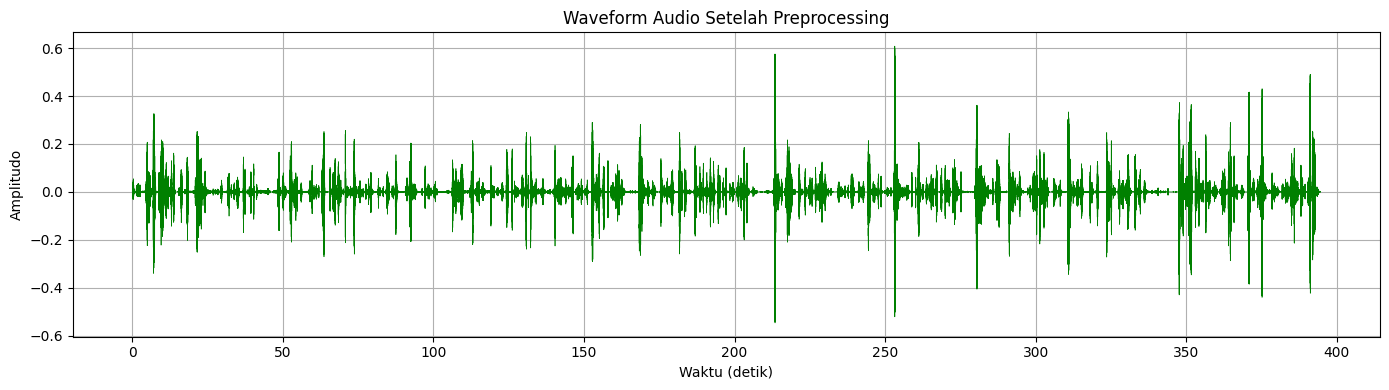

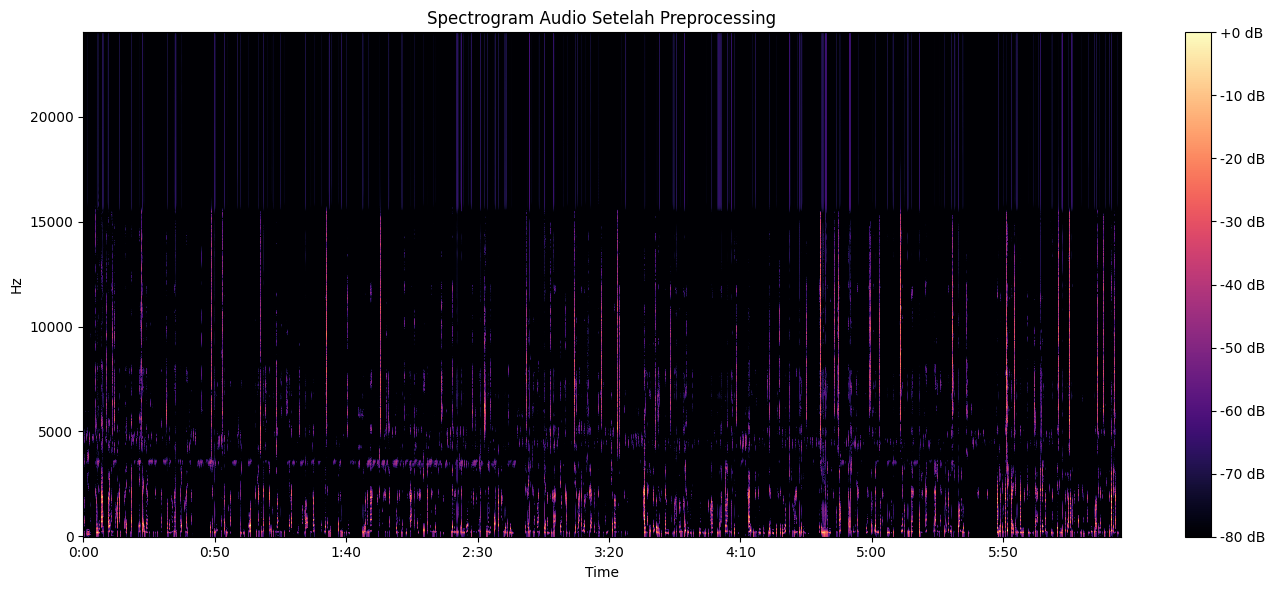

In [8]:
# Visualisasi Setelah Prepocessing
# Waveform setelah preprocessing
plt.figure(figsize=(14, 4))
time_proc = np.linspace(0, len(audio_processed)/sr, len(audio_processed))
plt.plot(time_proc, audio_processed, color='green', linewidth=0.5)
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.title('Waveform Audio Setelah Preprocessing')
plt.grid(True)
plt.tight_layout()
plt.show()

# Spectrogram setelah preprocessing
plt.figure(figsize=(14, 6))
D_proc = librosa.amplitude_to_db(np.abs(librosa.stft(audio_processed)), ref=np.max)
librosa.display.specshow(D_proc, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram Audio Setelah Preprocessing')
plt.tight_layout()
plt.show()

In [12]:
# Informasi Statistik
# Sebelum preprocessing
print(f"SEBELUM PREPROCESSING:")
print(f"  - Durasi: {len(audio_data)/sr:.2f} detik")
print(f"  - Amplitudo max: {np.max(np.abs(audio_data)):.4f}")
print(f"  - Amplitudo min: {np.min(audio_data):.4f}")
print(f"  - Amplitudo mean: {np.mean(np.abs(audio_data)):.4f}")
print(f"  - RMS: {np.sqrt(np.mean(audio_data**2)):.4f}")

# Setelah preprocessing
print(f"\nSETELAH PREPROCESSING:")
print(f"  - Durasi: {len(audio_processed)/sr:.2f} detik")
print(f"  - Amplitudo max: {np.max(np.abs(audio_processed)):.4f}")
print(f"  - Amplitudo min: {np.min(audio_processed):.4f}")
print(f"  - Amplitudo mean: {np.mean(np.abs(audio_processed)):.4f}")
print(f"  - RMS: {np.sqrt(np.mean(audio_processed**2)):.4f}")

SEBELUM PREPROCESSING:
  - Durasi: 124.99 detik
  - Amplitudo max: 0.5169
  - Amplitudo min: -0.5169
  - Amplitudo mean: 0.0326
  - RMS: 0.0571

SETELAH PREPROCESSING:
  - Durasi: 394.62 detik
  - Amplitudo max: 0.6079
  - Amplitudo min: -0.5467
  - Amplitudo mean: 0.0072
  - RMS: 0.0204
